# Machine Learning Classification Project
## Drug Recommendation System

This notebook demonstrates a complete **classification workflow** in Machine Learning, from data understanding to model evaluation.

**Objective:**  
Predict the type of drug prescribed to a patient based on medical attributes.

**Type of ML Problem:**  
Supervised Learning → Classification

## 1. Problem Definition

Doctors prescribe different drugs based on patient conditions such as:
- Age
- Sex
- Blood Pressure
- Cholesterol
- Sodium to Potassium Ratio

The goal is to build a classification model that predicts the **Drug type**.


## 2. Import Required Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

## 3. Load the Dataset

In [10]:
data = pd.read_csv("drug_dataset.csv")
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


## 4. Exploratory Data Analysis (EDA)

EDA helps us:
- Understand the structure of the data
- Identify categorical and numerical features
- Detect missing values


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [14]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [ ]:
data['BP'].value_counts()

: 

## 5. Data Visualization

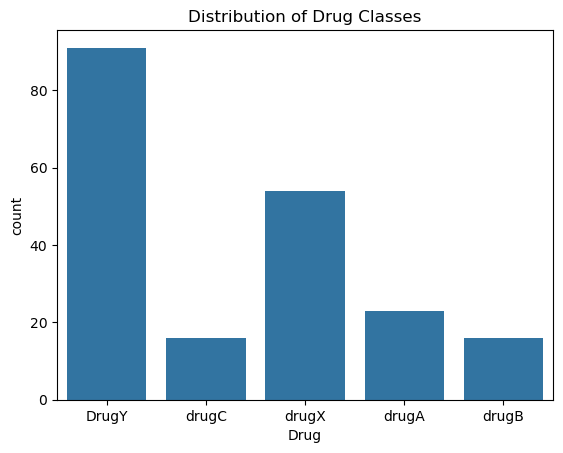

In [21]:
sns.countplot(x='Drug', data=data)
plt.title("Distribution of Drug Classes")
plt.show()

## 6. Data Preprocessing

Steps:
- Encode categorical variables
- Separate features and target
- Normalize numerical features


In [24]:
# Encode categorical columns
le = LabelEncoder()

data['Sex'] = le.fit_transform(data['Sex'])
data['BP'] = le.fit_transform(data['BP'])
data['Cholesterol'] = le.fit_transform(data['Cholesterol'])


In [26]:
# Features and target
X = data.drop('Drug', axis=1)
y = data['Drug']

## 7. Train-Test Split

Split data into:
- 80% Training
- 20% Testing

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Model Selection

We use **Decision Tree Classifier** because:
- Easy to interpret
- Handles categorical features well
- Suitable for classification tasks


In [32]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

## 9. Model Prediction

In [38]:
y_pred = model.predict(X_test)
y_pred

array(['drugX', 'DrugY', 'drugX', 'drugC', 'DrugY', 'DrugY', 'DrugY',
       'drugX', 'drugA', 'drugX', 'drugA', 'drugX', 'DrugY', 'drugA',
       'drugB', 'DrugY', 'drugB', 'drugX', 'drugC', 'DrugY', 'drugB',
       'drugX', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'drugC', 'drugX',
       'DrugY', 'drugX', 'DrugY', 'drugC', 'drugC', 'DrugY', 'drugA',
       'DrugY', 'drugX', 'drugA', 'DrugY', 'drugA'], dtype=object)

## 10. Model Evaluation

We evaluate the model using:
- Accuracy Score
- Confusion Matrix
- Classification Report


In [61]:
# Create a comparison DataFrame
comparison_df = pd.DataFrame({'Actual Drug': y_test.values,'Predicted Drug': y_pred})
comparison_df.head(10)

,Actual Drug,Predicted Drug
0,drugX,drugX
1,DrugY,DrugY
2,drugX,drugX
3,drugC,drugC
4,DrugY,DrugY
5,DrugY,DrugY
6,DrugY,DrugY
7,drugX,drugX
8,drugA,drugA
9,drugX,drugX


In [40]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

1.0

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       DrugY       1.00      1.00      1.00        15
       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [44]:
confusion_matrix(y_test, y_pred)

array([[15,  0,  0,  0,  0],
       [ 0,  6,  0,  0,  0],
       [ 0,  0,  3,  0,  0],
       [ 0,  0,  0,  5,  0],
       [ 0,  0,  0,  0, 11]], dtype=int64)

## 11. Results Interpretation

- High accuracy indicates good classification performance
- Precision and Recall show how well each drug class is predicted
- Confusion matrix highlights misclassifications
